In [96]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tradinglab.data_feed import DataFeed


torch.manual_seed(0)
np.random.seed(0)

In [97]:
feed = DataFeed.from_dir(
    "data/egx",
    symbols=["ABUK"]
)

print("Symbols:", feed.symbols)
print("Number of days:", len(feed.dates))


Symbols: ['ABUK']
Number of days: 2857


In [98]:
print("Close shape:", feed.close.shape)
print("Returns shape:", feed.returns.shape)

Close shape: (2857, 1)
Returns shape: (2857, 1)


In [99]:
# ============================================================
# 2. Get ABUK daily returns
# ============================================================

# Because we loaded only ABUK, column 0 is ABUK
returns = feed.returns[:, 0]

print("First 20 returns:")
print(returns[:20])

print("Number of returns:", len(returns))

First 20 returns:
[ 0.          0.01200003  0.00049412  0.          0.          0.
  0.          0.         -0.00030871 -0.02142632 -0.00290263  0.02518676
  0.         -0.02209884  0.03755847 -0.04654136  0.02252426  0.
  0.         -0.00156013]
Number of returns: 2857


In [100]:
print("Returns shape:", feed.returns.shape)

Returns shape: (2857, 1)


In [101]:
# ============================================================
# 3. Create supervised learning data
# ============================================================

LOOKBACK = 10

X = []
y = []
target_dates = []

for t in range(LOOKBACK, len(returns)):
    
    # Previous 10 returns
    X.append(returns[t-LOOKBACK:t])
    
    # Next return = target
    y.append(returns[t])
    
    # Date of the target return
    target_dates.append(feed.dates[t])


X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
target_dates = np.array(target_dates)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst X:")
print(X[0])

print("\nFirst y:")
print(y[0])

print("\nFirst target date:")
print(target_dates[0])

X shape: (2847, 10)
y shape: (2847,)

First X:
[ 0.          0.01200003  0.00049412  0.          0.          0.
  0.          0.         -0.00030871 -0.02142632]

First y:
-0.002902635

First target date:
2015-01-19 00:00:00


In [102]:
# ============================================================
# 4. Chronological 70/30 split
# ============================================================

split = int(len(X) * 0.70)

X_train_np = X[:split]
y_train_np = y[:split]

X_test_np = X[split:]
y_test_np = y[split:]

dates_train = target_dates[:split]
dates_test = target_dates[split:]


# Convert NumPy arrays to PyTorch tensors
X_train = torch.tensor(X_train_np)
y_train = torch.tensor(y_train_np)

X_test = torch.tensor(X_test_np)
y_test = torch.tensor(y_test_np)


print("Total samples:", len(X))

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining:")
print(dates_train[0], "→", dates_train[-1])

print("\nTesting:")
print(dates_test[0], "→", dates_test[-1])

Total samples: 2847
Train samples: 1992
Test samples: 855

Training:
2015-01-19 00:00:00 → 2023-01-15 00:00:00

Testing:
2023-01-16 00:00:00 → 2026-07-30 00:00:00


In [103]:
# ============================================================
# 5. MLP
# ============================================================

class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(LOOKBACK, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


model = MLP()

print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [104]:
# ============================================================
# TRAIN THE MLP
# ============================================================

EPOCHS = 300
LEARNING_RATE = 0.01

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

train_hist = []
test_hist = []

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    optimizer.zero_grad()

    train_pred = model(X_train)

    train_loss = nn.functional.mse_loss(
        train_pred,
        y_train
    )

    train_loss.backward()
    optimizer.step()

    # -------------------------
    # Testing
    # -------------------------
    model.eval()

    with torch.no_grad():
        test_pred = model(X_test)

        test_loss = nn.functional.mse_loss(
            test_pred,
            y_test
        )

    # Save losses
    train_hist.append(train_loss.detach().item())
    test_hist.append(test_loss.detach().item())


# CHECK
print("Number of training loss values:", len(train_hist))
print("Number of testing loss values:", len(test_hist))

print("First 5 train losses:", train_hist[:5])
print("First 5 test losses:", test_hist[:5])

print("Final train loss:", train_hist[-1])
print("Final test loss:", test_hist[-1])

Number of training loss values: 300
Number of testing loss values: 300
First 5 train losses: [0.009482390247285366, 0.0009425900643691421, 0.0020302683115005493, 0.0046053556725382805, 0.003969959914684296]
First 5 test losses: [0.0011215987615287304, 0.0022022214252501726, 0.00477601820603013, 0.004144343547523022, 0.002112159738317132]
Final train loss: 0.0004681669524870813
Final test loss: 0.0006901797605678439


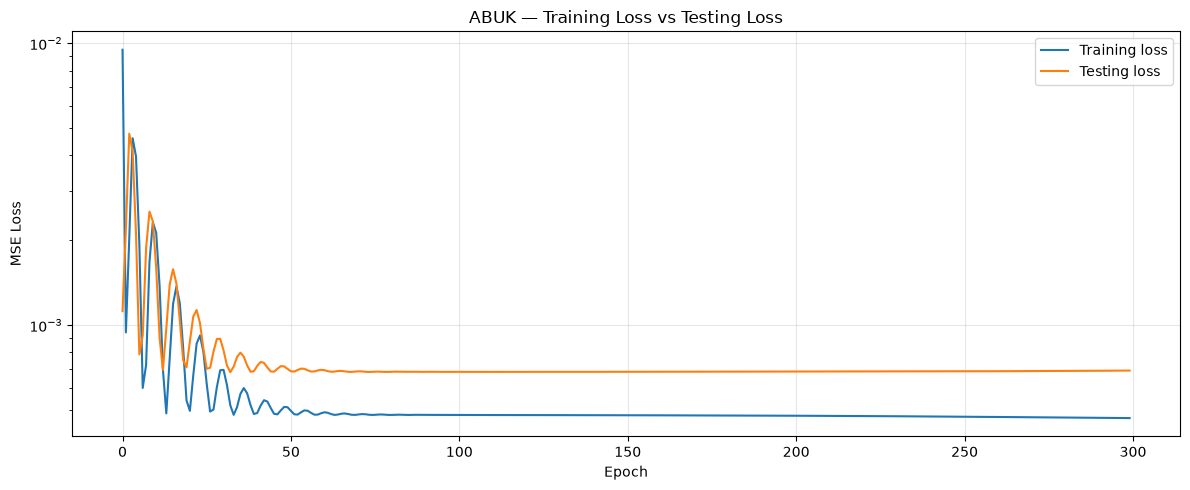

In [105]:
# ============================================================
# 7. Training Loss vs Testing Loss
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    train_hist,
    label="Training loss"
)

plt.plot(
    test_hist,
    label="Testing loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title("ABUK — Training Loss vs Testing Loss")

plt.yscale("log")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [106]:
# ============================================================
# 8. Predictions
# ============================================================

model.eval()

with torch.no_grad():

    train_pred = model(X_train).numpy()
    test_pred = model(X_test).numpy()


print("Train predictions:", train_pred.shape)
print("Test predictions:", test_pred.shape)

Train predictions: (1992,)
Test predictions: (855,)


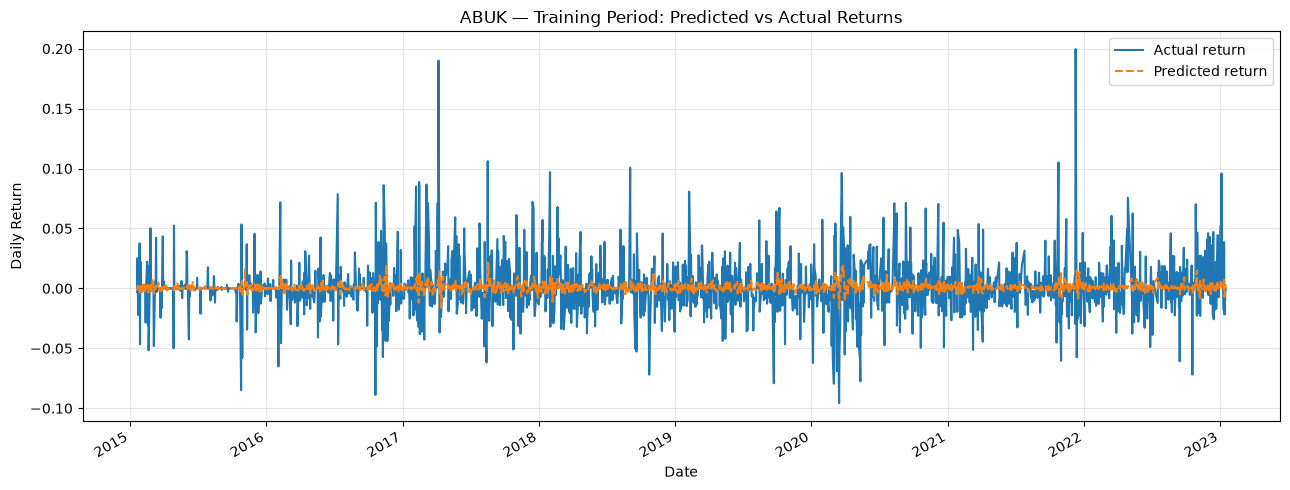

In [107]:
# ============================================================
# 9. Training Period
# ============================================================

plt.figure(figsize=(13, 5))

plt.plot(
    dates_train,
    y_train_np,
    label="Actual return"
)

plt.plot(
    dates_train,
    train_pred,
    label="Predicted return",
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.title(
    "ABUK — Training Period: Predicted vs Actual Returns"
)

plt.grid(alpha=0.3)
plt.legend()

plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

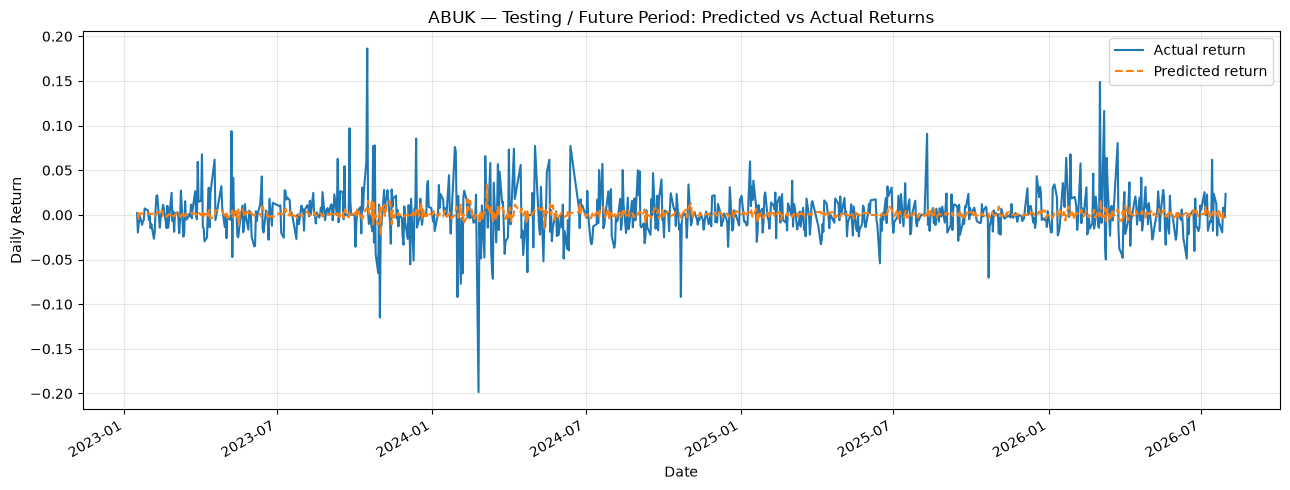

In [108]:
# ============================================================
# 10. Testing / Future Period
# ============================================================

plt.figure(figsize=(13, 5))

plt.plot(
    dates_test,
    y_test_np,
    label="Actual return"
)

plt.plot(
    dates_test,
    test_pred,
    label="Predicted return",
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.title(
    "ABUK — Testing / Future Period: Predicted vs Actual Returns"
)

plt.grid(alpha=0.3)
plt.legend()

plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

In [109]:
# ============================================================
# 11. Final Metrics
# ============================================================

train_mse = np.mean(
    (train_pred - y_train_np) ** 2
)

test_mse = np.mean(
    (test_pred - y_test_np) ** 2
)

print(f"Train MSE: {train_mse:.8f}")
print(f"Test MSE:  {test_mse:.8f}")

Train MSE: 0.00046807
Test MSE:  0.00069018


In [69]:
train_rmse = np.sqrt(0.00047826)
test_rmse = np.sqrt(0.00068509)

print(train_rmse)
print(test_rmse)

0.021869156362329115
0.026174223961752906
